# IN HIS NAME
## NNDL - HW Extra - Q2

In [22]:
import os
import time
import random

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
SEED = 42
SR = 16000
DURATION = 4
SAMPLES = SR * DURATION
N_MELS = 64
NUM_CLASSES = 10

LR = 1e-4
EPOCHS = 5
PATIENCE = 3
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
KAGGLE_DATASET_PATH = "../input/datasets/chrisfilo/urbansound8k"
CSV_PATH = os.path.join(KAGGLE_DATASET_PATH, "UrbanSound8K.csv")
AUDIO_DIR = KAGGLE_DATASET_PATH

In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [ ]:
def prepare_metadata(csv_path):
    df = pd.read_csv(csv_path)
    if 'classID' not in df.columns:
        le = LabelEncoder()
        df['classID'] = le.fit_transform(df['class'])
    return df

def stratified_split_df(df, test_size=0.1, val_size=0.1):
    X = df.index.values
    y = df['classID'].values
    X_rem, X_test = train_test_split(X, test_size=test_size, stratify=y, random_state=SEED)
    y_rem = df.loc[X_rem]['classID'].values
    val_relative = val_size / (1 - test_size)
    X_train, X_val = train_test_split(X_rem, test_size=val_relative, stratify=y_rem, random_state=SEED)
    return X_train, X_val, X_test

In [ ]:
class UrbanSoundDataset(Dataset):
    def __init__(self, df, indices):
        self.df = df.loc[indices].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fold = row['fold']
        filename = row['slice_file_name']
        path = os.path.join(AUDIO_DIR, f"fold{fold}", filename)

        y, _ = librosa.load(path, sr=SR, mono=True)

        if len(y) > SAMPLES:
            y = y[:SAMPLES]
        else:
            y = np.pad(y, (0, SAMPLES - len(y)))

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=SR,
            n_fft=1024,
            hop_length=512,
            n_mels=N_MELS
        )

        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.mean()) / (mel.std() + 1e-9)

        mel = torch.tensor(mel).unsqueeze(0).float()
        label = torch.tensor(row['classID']).long()

        return mel, label

In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct = 100 * trainable / total
    return total, trainable, pct

def train_model():
    df = prepare_metadata(CSV_PATH)
    train_idx, val_idx, test_idx = stratified_split_df(df)

    train_loader = DataLoader(UrbanSoundDataset(df, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(UrbanSoundDataset(df, val_idx), batch_size=BATCH_SIZE)
    test_loader = DataLoader(UrbanSoundDataset(df, test_idx), batch_size=BATCH_SIZE)

    model = SimpleCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR)

    total_params, trainable_params, pct = count_parameters(model)

    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[], 'epoch_time':[]}

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        start_time = time.time()
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0

        for X,y in train_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()*X.size(0)
            train_preds.extend(out.argmax(1).cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for X,y in val_loader:
                X,y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                loss = criterion(out,y)
                val_loss += loss.item()*X.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

        epoch_time = time.time() - start_time

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Time={epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model)

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for X,y in test_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            test_preds.extend(out.argmax(1).cpu().numpy())
            test_labels.extend(y.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    test_error = 1 - test_acc
    cm = confusion_matrix(test_labels, test_preds)

    print("\n===== TEST RESULTS =====")
    print("Accuracy:", test_acc)
    print("F1 (Macro):", test_f1)
    print("Error:", test_error)
    print("Trainable Params:", trainable_params)
    print("Total Params:", total_params)
    print("Trainable %:", pct)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss over Epochs")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.scatter(trainable_params, test_acc)
    plt.xscale('log')
    plt.xlabel("Trainable Parameters")
    plt.ylabel("Test Accuracy")
    plt.title("Model Size vs Accuracy")
    plt.show()

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)
        self.global_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

Epoch 1: Train Acc=0.2885 | Val Acc=0.4039 | Time=152.26s
Epoch 2: Train Acc=0.4516 | Val Acc=0.5114 | Time=147.98s
Epoch 3: Train Acc=0.4987 | Val Acc=0.5206 | Time=147.89s
Epoch 4: Train Acc=0.5305 | Val Acc=0.5183 | Time=150.78s
Epoch 5: Train Acc=0.5631 | Val Acc=0.5595 | Time=149.80s

===== TEST RESULTS =====
Accuracy: 0.5652173913043478
F1 (Macro): 0.5153390316412023
Error: 0.4347826086956522
Trainable Params: 24170
Total Params: 24170
Trainable %: 100.0


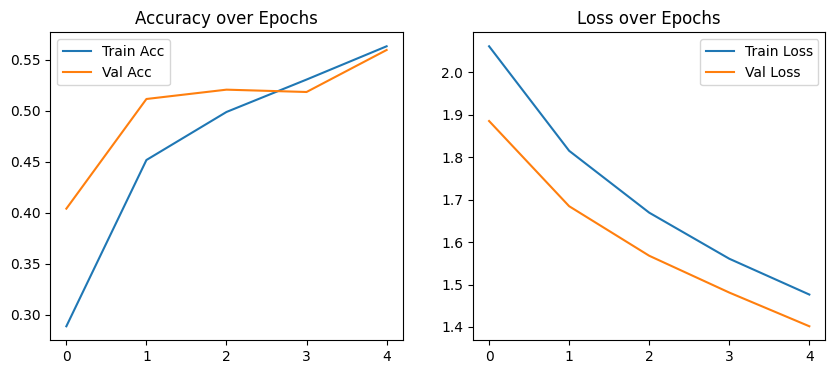

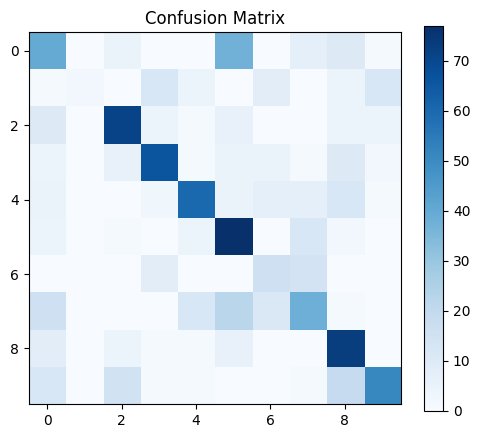

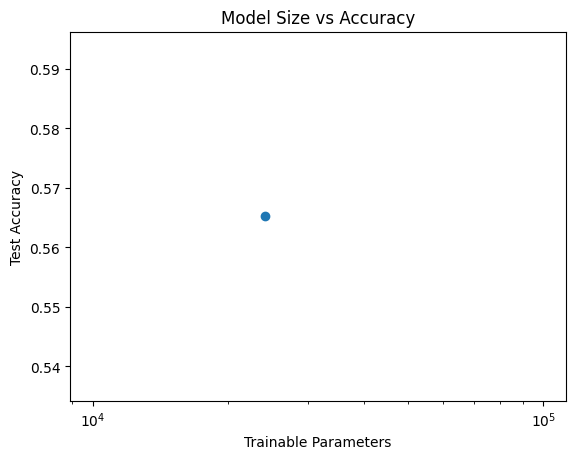

In [30]:
train_model()

# Model-2 

In [31]:
from transformers import Wav2Vec2Model

2026-02-18 00:43:21.899890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771375402.136721     564 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771375402.208028     564 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771375402.795850     564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771375402.795896     564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771375402.795899     564 computation_placer.cc:177] computation placer alr

In [ ]:
class UrbanSoundDatasetWav2Vec(Dataset):
    def __init__(self, df, indices):
        self.df = df.loc[indices].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fold = row['fold']
        filename = row['slice_file_name']
        path = os.path.join(AUDIO_DIR, f"fold{fold}", filename)
        waveform, _ = librosa.load(path, sr=SR, mono=True)
        if len(waveform) > SAMPLES:
            waveform = waveform[:SAMPLES]
        else:
            waveform = np.pad(waveform, (0, SAMPLES - len(waveform)))

        waveform = torch.tensor(waveform).float()
        label = torch.tensor(row['classID']).long()

        return waveform, label


In [ ]:
class Wav2Vec2Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        hidden_size = self.wav2vec.config.hidden_size
        self.classifier = nn.Linear(hidden_size, NUM_CLASSES)

    def forward(self, x):
        outputs = self.wav2vec(x)
        hidden_states = outputs.last_hidden_state
        pooled = hidden_states.mean(dim=1)

        logits = self.classifier(pooled)

        return logits


In [ ]:
def train_wav2vec2_model():

    df = prepare_metadata(CSV_PATH)
    train_idx, val_idx, test_idx = stratified_split_df(df)

    train_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, val_idx), batch_size=BATCH_SIZE)
    test_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, test_idx), batch_size=BATCH_SIZE)

    model = Wav2Vec2Classifier().to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LR)

    total_params, trainable_params, pct = count_parameters(model)

    print("Total Parameters:", total_params)
    print("Trainable Parameters:", trainable_params)
    print("Trainable %:", pct)


    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[], 'epoch_time':[]}

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        start_time = time.time()
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0

        for X,y in train_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()*X.size(0)
            train_preds.extend(out.argmax(1).cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for X,y in val_loader:
                X,y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                loss = criterion(out,y)
                val_loss += loss.item()*X.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

        epoch_time = time.time() - start_time

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Time={epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model)

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for X,y in test_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            test_preds.extend(out.argmax(1).cpu().numpy())
            test_labels.extend(y.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    test_error = 1 - test_acc
    cm = confusion_matrix(test_labels, test_preds)

    print("\n===== TEST RESULTS =====")
    print("Accuracy:", test_acc)
    print("F1 (Macro):", test_f1)
    print("Error:", test_error)
    print("Trainable Params:", trainable_params)
    print("Total Params:", total_params)
    print("Trainable %:", pct)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss over Epochs")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.scatter(trainable_params, test_acc)
    plt.xscale('log')
    plt.xlabel("Trainable Parameters")
    plt.ylabel("Test Accuracy")
    plt.title("Model Size vs Accuracy")
    plt.show()

config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Total Parameters: 94379402
Trainable Parameters: 94379402
Trainable %: 100.0


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Epoch 1: Train Acc=0.5272 | Val Acc=0.7471 | Time=721.20s
Epoch 2: Train Acc=0.7940 | Val Acc=0.8181 | Time=720.43s
Epoch 3: Train Acc=0.8737 | Val Acc=0.8535 | Time=720.62s
Epoch 4: Train Acc=0.8903 | Val Acc=0.8856 | Time=720.81s
Epoch 5: Train Acc=0.9257 | Val Acc=0.8833 | Time=721.23s

===== TEST RESULTS =====
Accuracy: 0.8810068649885584
F1 (Macro): 0.880505457654705
Error: 0.1189931350114416
Trainable Params: 94379402
Total Params: 94379402
Trainable %: 100.0


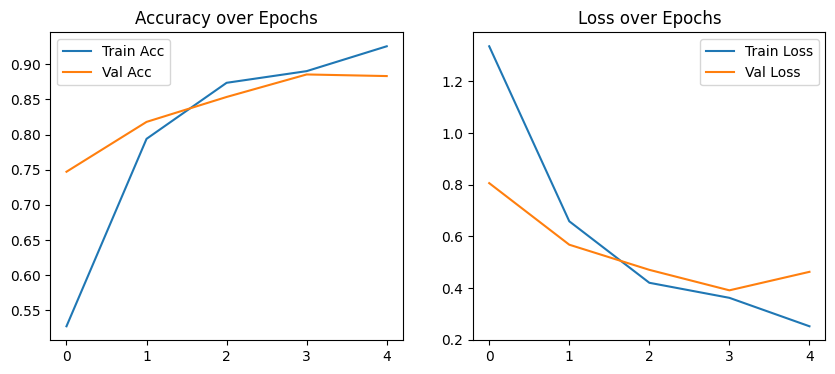

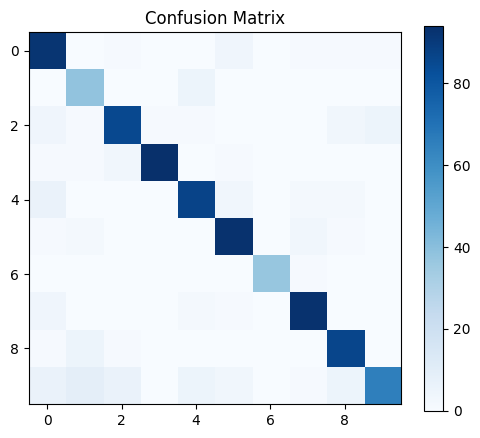

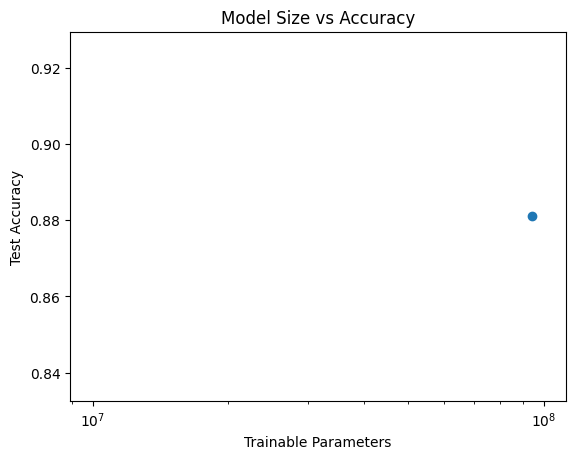

In [35]:
train_wav2vec2_model()

# Model-3

In [ ]:
class Wav2Vec2FrozenClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        for param in self.wav2vec.parameters():
            param.requires_grad = False

        hidden_size = self.wav2vec.config.hidden_size
        self.classifier = nn.Linear(hidden_size, NUM_CLASSES)

    def forward(self, x):
        with torch.no_grad():  
            outputs = self.wav2vec(x)
            hidden_states = outputs.last_hidden_state

        pooled = hidden_states.mean(dim=1)
        logits = self.classifier(pooled)

        return logits


In [ ]:
def train_wav2vec2_frozen_model():

    df = prepare_metadata(CSV_PATH)
    train_idx, val_idx, test_idx = stratified_split_df(df)

    train_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, val_idx), batch_size=BATCH_SIZE)
    test_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, test_idx), batch_size=BATCH_SIZE)

    model = Wav2Vec2FrozenClassifier().to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

    total_params, trainable_params, pct = count_parameters(model)

    print("Total Parameters:", total_params)
    print("Trainable Parameters:", trainable_params)
    print("Trainable %:", pct)

    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[], 'epoch_time':[]}

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        start_time = time.time()
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0

        for X,y in train_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()*X.size(0)
            train_preds.extend(out.argmax(1).cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for X,y in val_loader:
                X,y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                loss = criterion(out,y)
                val_loss += loss.item()*X.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

        epoch_time = time.time() - start_time

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Time={epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model)

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for X,y in test_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            test_preds.extend(out.argmax(1).cpu().numpy())
            test_labels.extend(y.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    test_error = 1 - test_acc
    cm = confusion_matrix(test_labels, test_preds)

    print("\n===== TEST RESULTS =====")
    print("Accuracy:", test_acc)
    print("F1 (Macro):", test_f1)
    print("Error:", test_error)
    print("Trainable Params:", trainable_params)
    print("Total Params:", total_params)
    print("Trainable %:", pct)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss over Epochs")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.scatter(trainable_params, test_acc)
    plt.xscale('log')
    plt.xlabel("Trainable Parameters")
    plt.ylabel("Test Accuracy")
    plt.title("Model Size vs Accuracy")
    plt.show()

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Total Parameters: 94379402
Trainable Parameters: 7690
Trainable %: 0.008147964319587446


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Epoch 1: Train Acc=0.2889 | Val Acc=0.3284 | Time=249.33s


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


...

Epoch 3: Train Acc=0.4668 | Val Acc=0.3890 | Time=246.99s


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Epoch 4: Train Acc=0.4936 | Val Acc=0.4085 | Time=247.28s


/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Epoch 5: Train Acc=0.5063 | Val Acc=0.4165 | Time=246.27s

===== TEST RESULTS =====
Accuracy: 0.39359267734553777
F1 (Macro): 0.36944513016615643
Error: 0.6064073226544622
Trainable Params: 7690
Total Params: 94379402
Trainable %: 0.008147964319587446


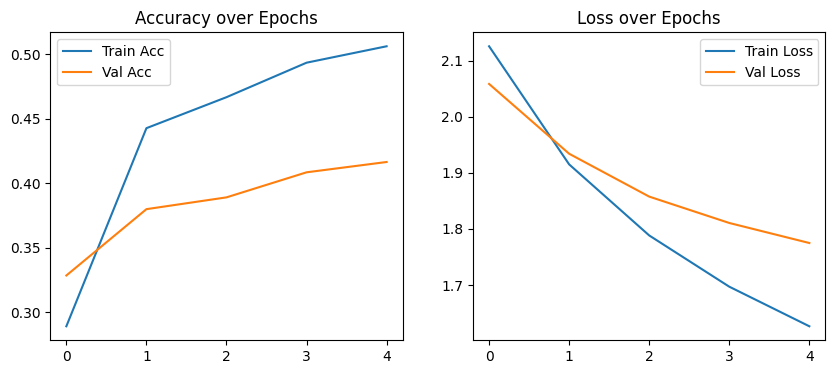

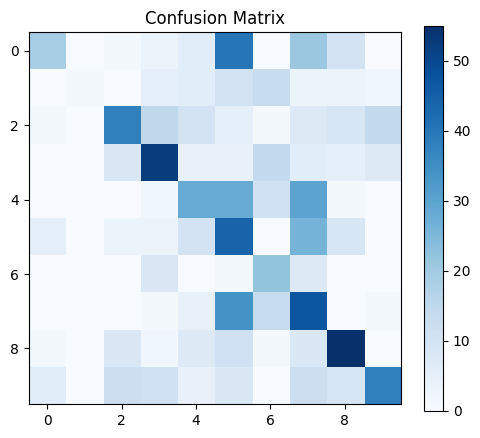

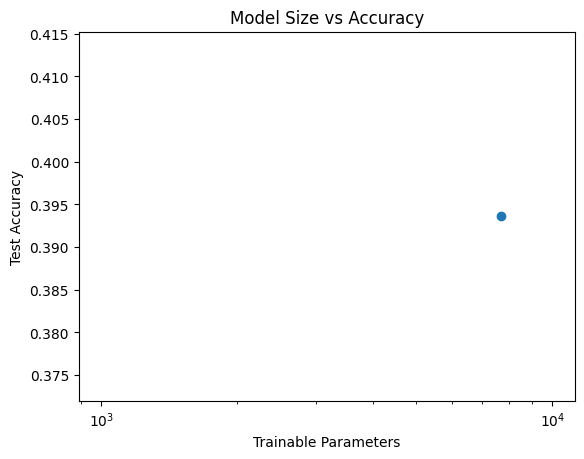

In [38]:
train_wav2vec2_frozen_model()

# Model-4

In [ ]:
class Wav2Vec2PartialFreeze(nn.Module):
    def __init__(self, freeze_layers=6):
        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")

        for param in self.wav2vec.feature_extractor.parameters():
            param.requires_grad = False

        for layer in self.wav2vec.encoder.layers[:freeze_layers]:
            for param in layer.parameters():
                param.requires_grad = False

        hidden_size = self.wav2vec.config.hidden_size
        self.classifier = nn.Linear(hidden_size, NUM_CLASSES)

    def forward(self, x):
        outputs = self.wav2vec(x)
        hidden_states = outputs.last_hidden_state

        pooled = hidden_states.mean(dim=1)
        logits = self.classifier(pooled)

        return logits


In [ ]:
def train_wav2vec2_partial_freeze():

    df = prepare_metadata(CSV_PATH)
    train_idx, val_idx, test_idx = stratified_split_df(df)

    train_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, val_idx), batch_size=BATCH_SIZE)
    test_loader = DataLoader(UrbanSoundDatasetWav2Vec(df, test_idx), batch_size=BATCH_SIZE)

    model = Wav2Vec2PartialFreeze(freeze_layers=6).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

    total_params, trainable_params, pct = count_parameters(model)

    print("Total Parameters:", total_params)
    print("Trainable Parameters:", trainable_params)
    print("Trainable %:", pct)

    history = {'train_acc':[], 'val_acc':[], 'train_loss':[], 'val_loss':[], 'epoch_time':[]}

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(EPOCHS):
        start_time = time.time()
        model.train()
        train_preds, train_labels = [], []
        train_loss = 0

        for X,y in train_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out,y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()*X.size(0)
            train_preds.extend(out.argmax(1).cpu().numpy())
            train_labels.extend(y.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for X,y in val_loader:
                X,y = X.to(DEVICE), y.to(DEVICE)
                out = model(X)
                loss = criterion(out,y)
                val_loss += loss.item()*X.size(0)
                val_preds.extend(out.argmax(1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

        epoch_time = time.time() - start_time

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_time'].append(epoch_time)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Time={epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered")
                break

    model.load_state_dict(best_model)

    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for X,y in test_loader:
            X,y = X.to(DEVICE), y.to(DEVICE)
            out = model(X)
            test_preds.extend(out.argmax(1).cpu().numpy())
            test_labels.extend(y.cpu().numpy())

    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds, average='macro')
    test_error = 1 - test_acc
    cm = confusion_matrix(test_labels, test_preds)

    print("\n===== TEST RESULTS =====")
    print("Accuracy:", test_acc)
    print("F1 (Macro):", test_f1)
    print("Error:", test_error)
    print("Trainable Params:", trainable_params)
    print("Total Params:", total_params)
    print("Trainable %:", pct)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.legend()
    plt.title("Accuracy over Epochs")

    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Loss over Epochs")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.show()

    plt.figure()
    plt.scatter(trainable_params, test_acc)
    plt.xscale('log')
    plt.xlabel("Trainable Parameters")
    plt.ylabel("Test Accuracy")
    plt.title("Model Size vs Accuracy")
    plt.show()

/usr/local/lib/python3.12/dist-packages/transformers/configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Total Parameters: 94379402
Trainable Parameters: 47651722
Trainable %: 50.489535841729534
Epoch 1: Train Acc=0.6218 | Val Acc=0.7002 | Time=608.27s
Epoch 2: Train Acc=0.8279 | Val Acc=0.7243 | Time=606.72s
Epoch 3: Train Acc=0.8909 | Val Acc=0.8089 | Time=610.81s
Epoch 4: Train Acc=0.9185 | Val Acc=0.8204 | Time=611.38s
Epoch 5: Train Acc=0.9407 | Val Acc=0.7998 | Time=608.07s

===== TEST RESULTS =====
Accuracy: 0.8009153318077803
F1 (Macro): 0.8105959044841056
Error: 0.1990846681922197
Trainable Params: 47651722
Total Params: 94379402
Trainable %: 50.489535841729534


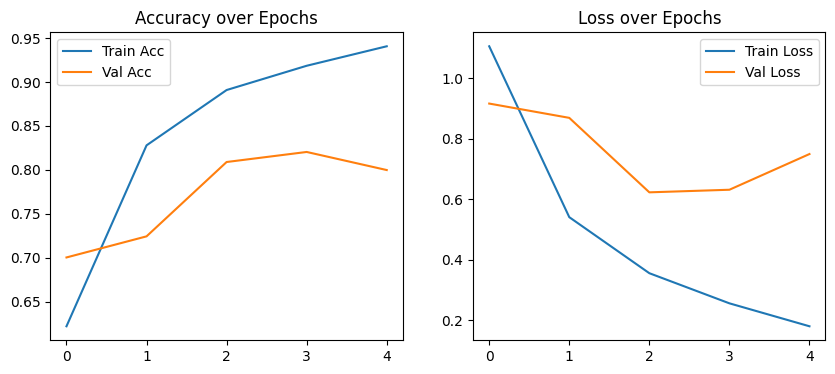

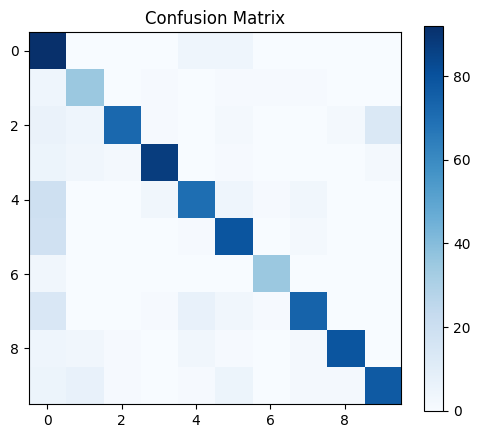

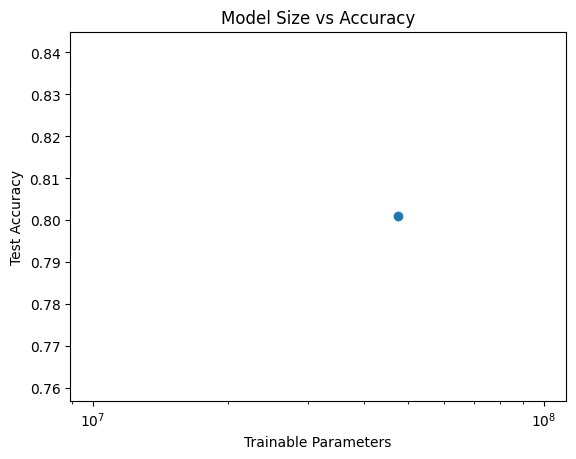

In [41]:
train_wav2vec2_partial_freeze()